#INFORMACIÓN GENERAL


UNIVERSIDAD NACIONAL DE SAN ANTONIO ABAD DEL CUSCO

INGENIERÍA INFORMÁTICA Y DE SISTEMAS

INTELIGENCIA ARTIFICIAL

LABORATORIO 03: POO Y AGENTES INTELIGENTES

**Agentes inteligentes**

#AGENTES INTELIGENTES


##Conceptos básicos

Wooldridge & Jennings (1995) definen a un agente como “un sistema de computación situada en algún entorno, que es capaz de una acción autónoma y flexible para alcanzar sus objetivos de diseño.”

De esta definición se desprende que es un sistema de software (hardware) con las siguientes propiedades fundamentales:
- Autonomía
- Habilidad social
- Reactividad
- Proactividad


Según Norvig &Russel (Russel & Norvig 2009) “un agente inteligente es aquél que puede percibir su ambiente mediante sensores y actuar sobre ese mundo mediante efectores (o actuadores)”.
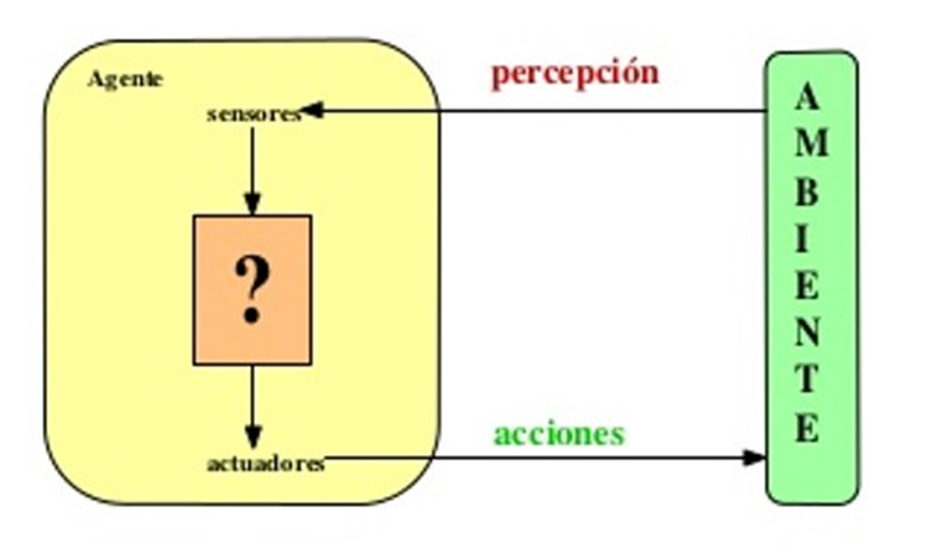

Ejemplo: Un taxi con piloto automático.

##Implementación de agentes inteligentes

###Ejemplo de agente inteligente Tabla

Máquina expendedora basada en una tabla

Se utiliza una estructura de datos diccionario, donde, se almacena la relación de todas las posibles secuencias de percepciones con la acción que corresponde a cada secuencia.

$TABLA = \left\lbrace\ Secuencia\hspace{3mm}de\hspace{3mm} percepciones:Acción, ...\right\rbrace$

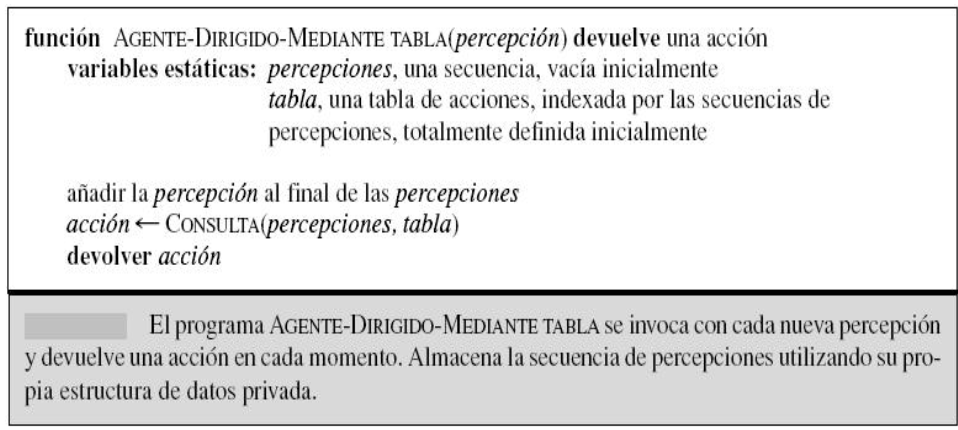

In [ ]:
ACCIONES = {'moneda':'pedir-codigo',
            'moneda,a1':'servir-bebida1',
            'moneda,a2':'servir-bebida2',
            'moneda,a3':'servir-bebida3',
            'moneda,a1,moneda':'pedir-codigo',
            'moneda,a2,moneda':'pedir-codigo',
            'moneda,a3,moneda':'pedir-codigo',
            'moneda,a1,moneda,a1':'servir-bebida1',
            'moneda,a1,moneda,a2':'servir-bebida2',
            'moneda,a1,moneda,a3':'servir-bebida3',
            'moneda,a2,moneda,a1':'servir-bebida1',
            'moneda,a2,moneda,a2':'servir-bebida2',
            'moneda,a2,moneda,a3':'servir-bebida3',
            'moneda,a3,moneda,a1':'servir-bebida1',
            'moneda,a3,moneda,a2':'servir-bebida2',
            'moneda,a3,moneda,a3':'servir-bebida3'}

class AgenteTabla:
  ''' Agente racional de tipo tabla. '''

  def __init__(self, acciones):
    self.acciones = acciones
    self.percepciones = ''

  def actuar(self, percepcion, accion_basica=''):
    '''Actúa según la percepción, devolviendo una acción. '''
    if not percepcion:
      return accion_basica
    if len(self.percepciones) != 0:
      self.percepciones += ','
    self.percepciones += percepcion
    if self.percepciones in self.acciones.keys():
      return self.acciones[self.percepciones]
    self.percepciones = ''
    return accion_basica


print('-- Agente Tabla: Máquina Expendedora --')
expendedora = AgenteTabla(ACCIONES)
percepcion = input('Indicar Percepción: ')
while percepcion:
  accion = expendedora.actuar(percepcion, 'reiniciarse')
  print(accion)
  percepcion = input('Indicar Percepción: ')



-- Agente Tabla: Máquina Expendedora --


###Ejemplo de agente inteligente Reactivo Simple

Máquina expendedora como un agente reactivo simple

Se basa en un conjunto de reglas. Cada regla describe una percepción y la acción correspondiente a dicha percepción. Se utiliza también una estructura de datos de tipo diccionario.

$REGLAS = \left\lbrace\ Percepción:Acción, ...\right\rbrace$


In [ ]:
REGLAS = {'moneda':'pedir-codigo',
          'a1':'servir-bebida1',
          'a2':'servir-bebida2',
          'a3':'servir-bebida3'}

class AgenteReactivoSimple:
  ''' Agente inteligente Reactivo simple. '''

  def __init__(self, reglas):
    self.reglas = reglas

  def actuar(self, percepcion, accion_basica=''):
    '''Actúa según la percepción, devolviendo una acción. '''
    if not percepcion:
      return accion_basica
    if percepcion in self.reglas.keys():
      return self.reglas[percepcion]
    return accion_basica

print('-- Agente Reactivo Simple: Máquina Expendedora --')
expendedora = AgenteReactivoSimple(REGLAS)
percepcion = input('Indicar Percepción: ')
while percepcion:
  accion = expendedora.actuar(percepcion, 'reiniciarse')
  print(accion)
  percepcion = input('Indicar Percepción: ')



-- Agente Reactivo Simple: Máquina Expendedora --
Indicar Percepción: moneda
pedir-codigo
Indicar Percepción: a1
servir-bebida1
Indicar Percepción: moneda
pedir-codigo
Indicar Percepción: a3
servir-bebida3
Indicar Percepción: a2
servir-bebida2
Indicar Percepción: a1
servir-bebida1
Indicar Percepción: a5
reiniciarse
Indicar Percepción: 


###Ejemplo de agente inteligente Reactivo Basado en un Modelo

Máquina expendedora basada en un modelo

Almacena información de la parte del mundo que ha visitado.

Se basa en:
- Un conjunto de reglas. Cada regla describe una
percepción y la acción correspondiente a dicha percepción; para lo cual, utiliza una estructura de datos de tipo diccionario.

  $REGLAS = \left\lbrace\ Percepción:Acción, ...\right\rbrace$

- Un modelo determinado por el estado actual, la última acción; de modo que, la nueva percepción determinará a que nuevo estado se cambia. Para lo cual, también se utiliza un diccionario.

  $Modelo = \left\lbrace\ left(Estado,Última\hspace{3mm} acción,Percepción) : nuevo\hspace{3mm} estado, ...\right\rbrace$


In [ ]:

class AgenteReactivoBasadoModelo:
  ''' Agente basado en modelo. '''

  def __init__(self, modelo, reglas, estado_inicial='', accion_inicial=''):
    self.modelo = modelo
    self.reglas = reglas
    self.estado_inicial = estado_inicial
    self.accion_inicial = accion_inicial
    self.accion = None
    self.estado = self.estado_inicial
    self.ult_accion = self.accion_inicial


  def actuar(self, percepcion):
    '''Actúa según la percepción, devolviendo una acción. '''
    if not percepcion:
      return self.accion_inicial
    clave = (self.estado, self.ult_accion, percepcion)
    if clave not in self.modelo.keys():
      self.accion = None
      self.estado = self.estado_inicial
      self.ult_accion = self.accion_inicial
      return self.accion_inicial
    self.estado = self.modelo[clave]
    if self.estado not in self.reglas.keys():
      self.accion = None
      self.estado = self.estado_inicial
      self.ult_accion = self.accion_inicial
    accion = self.reglas[self.estado]
    self.ult_accion = accion
    return accion

class MaquinaExpendedora:
  ''' Agente inteligente Máquina expendedora. '''
  # Percepciones: moneda, a1, a2, a3, servida.
  # Acciones: pedir-moneda, pedir-codigo, esperar.
  # Estados: sin-moneda, con_moneda, a1-servida, a2-servida, a3-servida.

  def __init__(self):
    # -- Las reglas definen las acciones que se pueden realizar en cada estado
    self.reglas = { 'sin-moneda':'pedir-moneda',
                    'con-moneda':'pedir-codigo',
                    'a1-servida':'esperar',
                    'a2-servida':'esperar',
                    'a3-servida':'esperar'}
    # -- El modelo está definido por el estado actual y cuál fue la última acción.
    #    Luego, si hay alguna percepción a qué estado cambia.
    self.modelo = {('sin-moneda', 'pedir-moneda', 'moneda'):'con-moneda',
                    ('con-moneda', 'pedir-codigo', 'a1'):'a1-servida',
                    ('con-moneda', 'pedir-codigo', 'a2'):'a2-servida',
                    ('con-moneda', 'pedir-codigo', 'a3'):'a3-servida',
                    ('a1-servida', 'esperar', 'servida'):'sin-moneda',
                    ('a2-servida', 'esperar', 'servida'):'sin-moneda',
                    ('a3-servida', 'esperar', 'servida'):'sin-moneda'}

    self.maquina_expendedora = AgenteReactivoBasadoModelo(self.modelo, self.reglas, 'sin-moneda', 'pedir-moneda')

  def actuar(self, percepcion):
    '''Actúa según la percepción, devolviendo una acción. '''
    return self.maquina_expendedora.actuar(percepcion)

print('-- Agente Reactivo Basado en modelo: Máquina Expendedora --')
expendedora = MaquinaExpendedora()
percepcion = input('Indicar Percepción: ')
while percepcion:
  accion = expendedora.actuar(percepcion)
  print(accion)
  percepcion = input('Indicar Percepción: ')



-- Agente Reactivo Basado en modelo: Máquina Expendedora --
pedir-moneda
pedir-moneda
pedir-moneda
pedir-codigo
esperar
pedir-moneda
